Install and Imports

In [ ]:
!pip install scikit-learn joblib scipy

import joblib
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from scipy.sparse import issparse


Load Feature Matrix/Data

In [ ]:
# Load feature matrix (X), labels (y), and preprocessing objects
X, y, tfidf, scaler = joblib.load("feature_matrix.pkl")

print("Type of X:", type(X))
if hasattr(X, "shape"):
    print("Shape of X:", X.shape)

print("Shape of y:", np.shape(y))

# If you used 0=Low, 1=Medium, 2=High
label_map_inv = {0: "Low", 1: "Medium", 2: "High"}

unique, counts = np.unique(y, return_counts=True)
print("\nLabel distribution:")
for lbl, cnt in zip(unique, counts):
    print(f"  {lbl} ({label_map_inv.get(int(lbl), '?')}): {cnt}")


Type of X: <class 'scipy.sparse._csr.csr_matrix'>
Shape of X: (30, 317)
Shape of y: (30,)

Label distribution:
  0 (Low): 5
  1 (Medium): 12
  2 (High): 13


Set Up K-Fold Cross Validation

In [ ]:
# Use 3-fold CV due to very small sample size
k = 3
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

print(f"Using K-Fold cross-validation with k={k}")


Using K-Fold cross-validation with k=3


Multinomial Logistic Regression (Baseline)

In [ ]:
log_reg = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)

scores_lr = cross_val_score(
    log_reg,
    X,
    y,
    cv=kfold,
    scoring='accuracy'
)

print("=== Multinomial Logistic Regression (No PCA) ===")
print("Fold accuracies:", scores_lr)
print("Mean accuracy:", scores_lr.mean())
print("Std deviation:", scores_lr.std())


=== Multinomial Logistic Regression (No PCA) ===
Fold accuracies: [0.9 0.7 0.9]
Mean accuracy: 0.8333333333333334
Std deviation: 0.09428090415820636


Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

scores_rf = cross_val_score(
    rf,
    X,
    y,
    cv=kfold,
    scoring='accuracy'
)

print("=== Random Forest (No PCA) ===")
print("Fold accuracies:", scores_rf)
print("Mean accuracy:", scores_rf.mean())
print("Std deviation:", scores_rf.std())


=== Random Forest (No PCA) ===
Fold accuracies: [0.7 0.5 0.8]
Mean accuracy: 0.6666666666666666
Std deviation: 0.12472191289246473


Gradient Boosting (no PCA, using dense X)

In [ ]:
# Convert X to dense only if needed (safe for small datasets)
if issparse(X):
    X_dense = X.toarray()
else:
    X_dense = X

gb = GradientBoostingClassifier(
    random_state=42
)

scores_gb = cross_val_score(
    gb,
    X_dense,
    y,
    cv=kfold,
    scoring='accuracy'
)

print("=== Gradient Boosting (No PCA) ===")
print("Fold accuracies:", scores_gb)
print("Mean accuracy:", scores_gb.mean())
print("Std deviation:", scores_gb.std())


=== Gradient Boosting (No PCA) ===
Fold accuracies: [0.6 0.6 0.8]
Mean accuracy: 0.6666666666666666
Std deviation: 0.09428090415820638


Logistic Regression with SVD (PCA-style)

In [ ]:
# Number of components to keep (you can experiment with 3, 5, 10, etc.)
n_components = 5

svd = TruncatedSVD(n_components=n_components, random_state=42)
log_reg_pca = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)

pipeline_lr_pca = Pipeline([
    ("svd", svd),
    ("clf", log_reg_pca)
])

scores_lr_pca = cross_val_score(
    pipeline_lr_pca,
    X,
    y,
    cv=kfold,
    scoring='accuracy'
)

print(f"=== Logistic Regression with SVD (n_components={n_components}) ===")
print("Fold accuracies:", scores_lr_pca)
print("Mean accuracy:", scores_lr_pca.mean())
print("Std deviation:", scores_lr_pca.std())

# Optional: fit once on full data to inspect explained variance
pipeline_lr_pca.fit(X, y)
explained = pipeline_lr_pca.named_steps["svd"].explained_variance_ratio_
print("\nExplained variance by components:", explained)
print("Total explained variance:", explained.sum())


=== Logistic Regression with SVD (n_components=5) ===
Fold accuracies: [0.8 0.6 0.9]
Mean accuracy: 0.7666666666666666
Std deviation: 0.12472191289246473

Explained variance by components: [0.18677549 0.15150112 0.11077577 0.0893495  0.08590167]
Total explained variance: 0.6243035623464626


Random Forest with SVD

In [ ]:
rf_pca = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

pipeline_rf_pca = Pipeline([
    ("svd", TruncatedSVD(n_components=n_components, random_state=42)),
    ("clf", rf_pca)
])

scores_rf_pca = cross_val_score(
    pipeline_rf_pca,
    X,
    y,
    cv=kfold,
    scoring='accuracy'
)

print(f"=== Random Forest with SVD (n_components={n_components}) ===")
print("Fold accuracies:", scores_rf_pca)
print("Mean accuracy:", scores_rf_pca.mean())
print("Std deviation:", scores_rf_pca.std())


=== Random Forest with SVD (n_components=5) ===
Fold accuracies: [0.9 0.6 0.9]
Mean accuracy: 0.7999999999999999
Std deviation: 0.14142135623730953


Gradient Boosting with SVD

In [ ]:
gb_pca = GradientBoostingClassifier(
    random_state=42
)

pipeline_gb_pca = Pipeline([
    ("svd", TruncatedSVD(n_components=n_components, random_state=42)),
    ("clf", gb_pca)
])

scores_gb_pca = cross_val_score(
    pipeline_gb_pca,
    X_dense if not issparse(X) else X,  # SVD can take sparse directly
    y,
    cv=kfold,
    scoring='accuracy'
)

print(f"=== Gradient Boosting with SVD (n_components={n_components}) ===")
print("Fold accuracies:", scores_gb_pca)
print("Mean accuracy:", scores_gb_pca.mean())
print("Std deviation:", scores_gb_pca.std())


=== Gradient Boosting with SVD (n_components=5) ===
Fold accuracies: [0.7 0.5 0.8]
Mean accuracy: 0.6666666666666666
Std deviation: 0.12472191289246473


Summary

In [ ]:
results = {
    "LogReg (no PCA)": (scores_lr.mean(), scores_lr.std()),
    "RandomForest (no PCA)": (scores_rf.mean(), scores_rf.std()),
    "GradBoost (no PCA)": (scores_gb.mean(), scores_gb.std()),
    f"LogReg + SVD (k={n_components})": (scores_lr_pca.mean(), scores_lr_pca.std()),
    f"RandomForest + SVD (k={n_components})": (scores_rf_pca.mean(), scores_rf_pca.std()),
    f"GradBoost + SVD (k={n_components})": (scores_gb_pca.mean(), scores_gb_pca.std())
}

print("=== Model Comparison (Mean Accuracy ± Std) ===")
for name, (mean_acc, std_acc) in results.items():
    print(f"{name:30s}: {mean_acc:.3f} ± {std_acc:.3f}")

=== Model Comparison (Mean Accuracy ± Std) ===
LogReg (no PCA)               : 0.833 ± 0.094
RandomForest (no PCA)         : 0.667 ± 0.125
GradBoost (no PCA)            : 0.667 ± 0.094
LogReg + SVD (k=5)            : 0.767 ± 0.125
RandomForest + SVD (k=5)      : 0.800 ± 0.141
GradBoost + SVD (k=5)         : 0.667 ± 0.125


LR + SVD and RF + SVD with 5, 10, 20 Components

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

components_list = [5, 10, 20]

results_pca = {}

for n_components in components_list:
    print(f"\n=== SVD with n_components = {n_components} ===")

    # Logistic Regression + SVD
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    log_reg_pca = LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        n_jobs=-1
    )

    pipeline_lr_pca = Pipeline([
        ("svd", svd),
        ("clf", log_reg_pca)
    ])

    scores_lr_pca = cross_val_score(
        pipeline_lr_pca,
        X,
        y,
        cv=kfold,
        scoring='accuracy'
    )

    print(f"LogReg + SVD (k={n_components}): {scores_lr_pca.mean():.3f} ± {scores_lr_pca.std():.3f}")
    results_pca[f"LogReg + SVD (k={n_components})"] = (scores_lr_pca.mean(), scores_lr_pca.std())

    # Random Forest + SVD
    rf_pca = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    pipeline_rf_pca = Pipeline([
        ("svd", TruncatedSVD(n_components=n_components, random_state=42)),
        ("clf", rf_pca)
    ])

    scores_rf_pca = cross_val_score(
        pipeline_rf_pca,
        X,
        y,
        cv=kfold,
        scoring='accuracy'
    )

    print(f"RandomForest + SVD (k={n_components}): {scores_rf_pca.mean():.3f} ± {scores_rf_pca.std():.3f}")
    results_pca[f"RandomForest + SVD (k={n_components})"] = (scores_rf_pca.mean(), scores_rf_pca.std())

print("\n=== Summary of SVD settings ===")
for name, (m, s) in results_pca.items():
    print(f"{name:30s}: {m:.3f} ± {s:.3f}")



=== SVD with n_components = 5 ===
LogReg + SVD (k=5): 0.767 ± 0.125
RandomForest + SVD (k=5): 0.800 ± 0.141

=== SVD with n_components = 10 ===
LogReg + SVD (k=10): 0.800 ± 0.141
RandomForest + SVD (k=10): 0.800 ± 0.141

=== SVD with n_components = 20 ===
LogReg + SVD (k=20): 0.833 ± 0.094
RandomForest + SVD (k=20): 0.800 ± 0.082

=== Summary of SVD settings ===
LogReg + SVD (k=5)            : 0.767 ± 0.125
RandomForest + SVD (k=5)      : 0.800 ± 0.141
LogReg + SVD (k=10)           : 0.800 ± 0.141
RandomForest + SVD (k=10)     : 0.800 ± 0.141
LogReg + SVD (k=20)           : 0.833 ± 0.094
RandomForest + SVD (k=20)     : 0.800 ± 0.082


2D SVD "PCA-style" scatterplot colored by class

Explained variance ratios (2 components): [0.18677549 0.15150112]
Total explained variance (2D): 0.33827661583189517


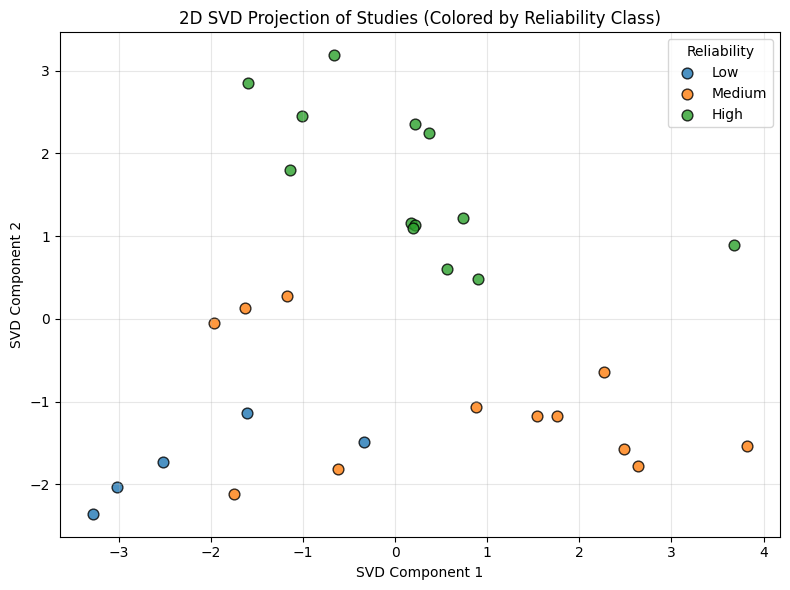

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import TruncatedSVD

# Make sure label_map_inv exists; if not, define it:
label_map_inv = {0: "Low", 1: "Medium", 2: "High"}

# 2D SVD for visualization
svd_vis = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_vis.fit_transform(X)

print("Explained variance ratios (2 components):", svd_vis.explained_variance_ratio_)
print("Total explained variance (2D):", svd_vis.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(8, 6))

classes = np.unique(y)
colors = {0: "tab:red", 1: "tab:orange", 2: "tab:blue"}

for c in classes:
    mask = (y == c)
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=label_map_inv.get(int(c), str(c)),
        alpha=0.8,
        s=60,
        edgecolor="k"
    )

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("2D SVD Projection of Studies (Colored by Reliability Class)")
plt.legend(title="Reliability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Linear SVM

In [ ]:
from sklearn.svm import LinearSVC

svm_clf = LinearSVC(
    class_weight="balanced"  # optional, but helps
)

scores_svm = cross_val_score(
    svm_clf, X, y, cv=kfold, scoring='accuracy'
)

print("Linear SVM accuracy:", scores_svm.mean(), scores_svm.std())


Linear SVM accuracy: 0.7999999999999999 0.14142135623730953


Evaluate BEST Model

In [ ]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
import numpy as np

def evaluate_model_kfold(model, X, y, kfold):
    accuracies = []
    cms = []
    reports = []

    fold = 1
    for train_idx, test_idx in kfold.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Fit on this fold
        model.fit(X_train, y_train)

        # Predict on validation fold
        y_pred = model.predict(X_test)

        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
        cms.append(cm)

        # Full classification report dictionary
        report = classification_report(
            y_test, y_pred,
            output_dict=True,
            labels=[0,1,2],
            target_names=["Low", "Medium", "High"]
        )
        reports.append(report)

        print(f"\n=== Fold {fold} ===")
        print("Accuracy:", acc)
        print("Confusion matrix:")
        print(cm)
        print("\nClassification report:")
        print(classification_report(
            y_test, y_pred,
            labels=[0,1,2],
            target_names=["Low", "Medium", "High"]
        ))

        fold += 1

    return accuracies, cms, reports


Run on Best Model (Lin Reg)

In [ ]:
best_model = log_reg  # OR svm_clf OR pipeline_lr_pca, etc.

accuracies, cms, reports = evaluate_model_kfold(best_model, X, y, kfold)



=== Fold 1 ===
Accuracy: 0.9
Confusion matrix:
[[0 0 0]
 [1 5 0]
 [0 0 4]]

Classification report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         0
      Medium       1.00      0.83      0.91         6
        High       1.00      1.00      1.00         4

    accuracy                           0.90        10
   macro avg       0.67      0.61      0.64        10
weighted avg       1.00      0.90      0.95        10


=== Fold 2 ===
Accuracy: 0.7
Confusion matrix:
[[0 2 1]
 [0 3 0]
 [0 0 4]]

Classification report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         3
      Medium       0.60      1.00      0.75         3
        High       0.80      1.00      0.89         4

    accuracy                           0.70        10
   macro avg       0.47      0.67      0.55        10
weighted avg       0.50      0.70      0.58        10


=== Fold 3 ===
Accuracy: 0.9
Confusio

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

Aggregate Metrics accross All Folds

In [ ]:
print("\n========================")
print("Overall Cross-Validated Accuracy")
print("========================")
print("Fold accuracies:", accuracies)
print("Mean accuracy:", np.mean(accuracies))
print("Std deviation:", np.std(accuracies))

# Aggregate confusion matrices
total_cm = sum(cms)
print("\n========================")
print("Aggregated Confusion Matrix (All Folds Combined)")
print("========================")
print(total_cm)

# Extract per-class F1 scores
avg_f1_low = np.mean([r['Low']['f1-score'] for r in reports if 'Low' in r])
avg_f1_med = np.mean([r['Medium']['f1-score'] for r in reports if 'Medium' in r])
avg_f1_high = np.mean([r['High']['f1-score'] for r in reports if 'High' in r])

print("\n========================")
print("Average F1-score per class (cross-validated)")
print("========================")
print("Low F1:    ", avg_f1_low)
print("Medium F1: ", avg_f1_med)
print("High F1:   ", avg_f1_high)



Overall Cross-Validated Accuracy
Fold accuracies: [0.9, 0.7, 0.9]
Mean accuracy: 0.8333333333333334
Std deviation: 0.09428090415820636

Aggregated Confusion Matrix (All Folds Combined)
[[ 2  2  1]
 [ 2 10  0]
 [ 0  0 13]]

Average F1-score per class (cross-validated)
Low F1:     0.26666666666666666
Medium F1:  0.8196969696969697
High F1:    0.9629629629629629


Checking for Most Important Features - Log Reg

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

# If you already have these, this cell just refits on the full data.
log_reg_full = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)
log_reg_full.fit(X, y)

rf_full = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X, y)

# Feature names: adjust this if you already have a list of names.
# If your features were originally in a DataFrame called df_features:
# feature_names = list(df_features.columns)

try:
    feature_names  # if already defined, this won't run
except NameError:
    feature_names = [f"feat_{i}" for i in range(X.shape[1])]

len(feature_names), X.shape[1]


(317, 317)

Log Reg Feature Importance

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Coefficients: shape (n_classes, n_features)
coef = log_reg_full.coef_

# Map class index to label for readability
class_labels = {0: "Low", 1: "Medium", 2: "High"}

def top_features_for_class(class_idx, top_n=15):
    """Return a DataFrame of top +/- features for a given class index."""
    class_name = class_labels[class_idx]
    class_coef = coef[class_idx]

    df = pd.DataFrame({
        "feature": feature_names,
        "coef": class_coef,
        "abs_coef": np.abs(class_coef)
    }).sort_values("abs_coef", ascending=False)

    print(f"\nTop {top_n} features for class: {class_name}")
    return df.head(top_n)

# Example: look at "High reliability" drivers
top_high = top_features_for_class(2, top_n=15)
top_high



Top 15 features for class: High


,feature,coef,abs_coef
1,feat_1,0.859448,0.859448
6,feat_6,-0.691353,0.691353
2,feat_2,-0.485594,0.485594
3,feat_3,-0.397208,0.397208
9,feat_9,0.384808,0.384808
5,feat_5,0.374445,0.374445
4,feat_4,0.268672,0.268672
8,feat_8,0.216083,0.216083
7,feat_7,0.197729,0.197729
12,feat_12,-0.156953,0.156953


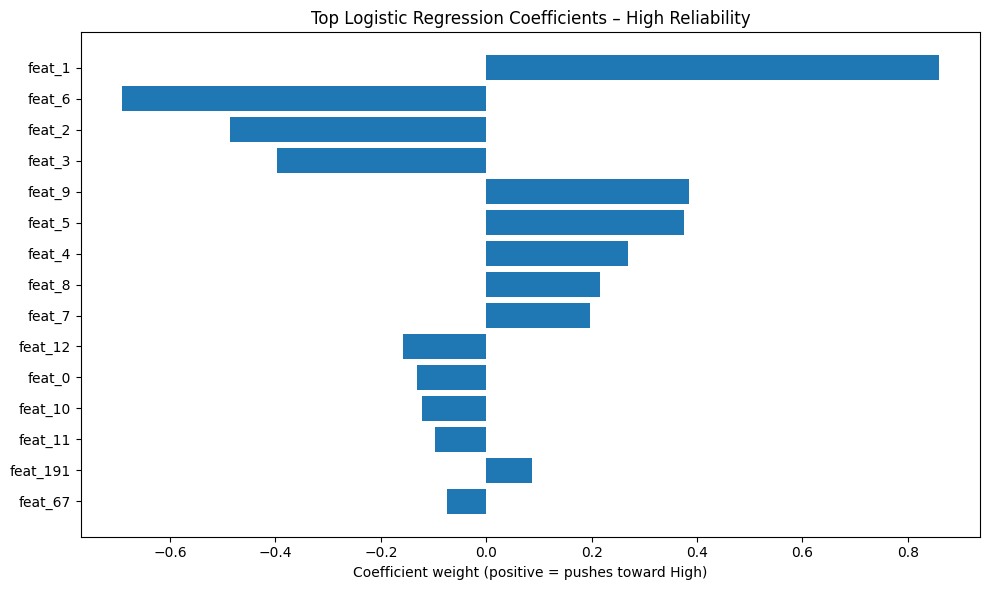

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_high["feature"], top_high["coef"])
plt.title("Top Logistic Regression Coefficients – High Reliability")
plt.xlabel("Coefficient weight (positive = pushes toward High)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


RF Feature Importance

In [ ]:
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_full.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(15)


,feature,importance
1,feat_1,0.046202
0,feat_0,0.036213
260,feat_260,0.026622
2,feat_2,0.024485
83,feat_83,0.017611
9,feat_9,0.015386
187,feat_187,0.014978
199,feat_199,0.014969
265,feat_265,0.014607
255,feat_255,0.014273


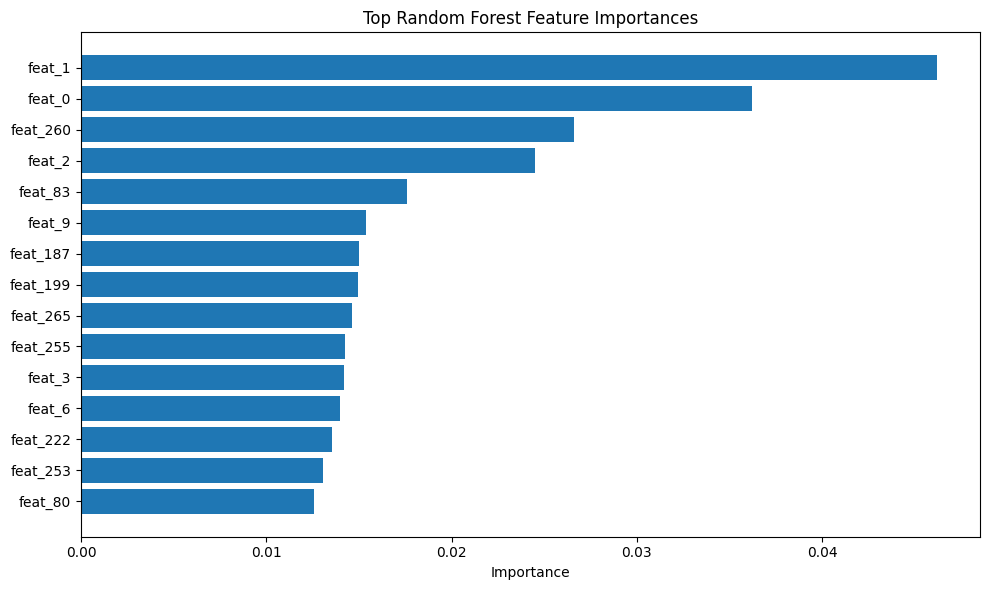

In [ ]:
top_n = 15
top_rf = rf_importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
